[Step 1] 라이브러리 설치 및 데이터 로드

In [ ]:
!pip install catboost pytorch-tabnet optuna shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Models
from catboost import CatBoostRegressor, Pool
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
import optuna
import shap

try:
    df = pd.read_csv('icu_final_feature_set.csv')
    print(f"데이터 로드 완료: {df.shape}")
except FileNotFoundError:
    print("오류: 'icu_final_feature_set.csv' 파일을 업로드해주세요.")
    raise

# 3. 타겟 변수 로그 변환
df['log_los'] = np.log1p(df['los'])
target = 'log_los'

# 4. 피처(X)와 타겟(y) 분리 및 피처 선별
# (1) 기본 제거 컬럼
base_drop_cols = ['los', 'log_los', 'anchor_year']

# (2) Ablation Study 결과 하위 중요도 피처 제거
low_imp_features = [
    'Temp_48h_min', 'AnionGap_max', 'GCS_Eye_48h_max', 'RR_48h_min',
    'GCS_Motor_48h_min', 'race_simplified', 'gender', 'Bicarbonate_min',
    'GCS_Verbal_48h_min', 'GCS_Motor_48h_max'
]

# 최종 제거 컬럼 리스트
drop_cols = base_drop_cols + low_imp_features

print(f"제거되는 피처 목록 ({len(drop_cols)}개): {drop_cols}")

X = df.drop(columns=drop_cols)
y = df[target]

print(f"X Shape (피처 제거 후): {X.shape}, y Shape: {y.shape}")

# 5. 범주형/수치형 변수 구분
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"범주형 변수({len(cat_cols)}): {cat_cols}")


[Step 1] 데이터 로드 및 전처리
데이터 로드 완료: (16394, 55)
제거되는 피처 목록 (13개): ['los', 'log_los', 'anchor_year', 'Temp_48h_min', 'AnionGap_max', 'GCS_Eye_48h_max', 'RR_48h_min', 'GCS_Motor_48h_min', 'race_simplified', 'gender', 'Bicarbonate_min', 'GCS_Verbal_48h_min', 'GCS_Motor_48h_max']
X Shape (피처 제거 후): (16394, 43), y Shape: (16394,)
범주형 변수(0): []


[Step 2] 데이터 전처리 및 분할

In [ ]:
# 1. 전처리 (Label Encoding)
X_processed = X.copy()

# Label Encoding (범주형)
for col in cat_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X[col].astype(str))

# 2. 데이터 분할 (Train/Val/Test = 70:15:15)
# 먼저 Train+Val / Test 분리 (85:15)
X_train_val, X_test, y_train_val, y_test = train_test_split(X_processed, y, test_size=0.15, random_state=42)

# 다시 Train / Val 분리 (0.85 * 0.1765 ~= 0.15)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42)

print(f"Train 셋 크기: {X_train.shape}")
print(f"Valid 셋 크기: {X_val.shape}")
print(f"Test  셋 크기: {X_test.shape}")

Train 셋 크기: (11474, 43)
Valid 셋 크기: (2460, 43)
Test  셋 크기: (2460, 43)


[Step 3] CatBoost 모델링 (튜닝 및 학습)

In [ ]:
print("\n--- [1] CatBoost 모델링 ---")

# 1. CatBoost 전용 Pool 생성
cat_features_indices = [X_processed.columns.get_loc(c) for c in cat_cols]
train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
val_pool = Pool(X_val, y_val, cat_features=cat_features_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_features_indices)

# 2. Optuna 목적 함수 정의
def objective_cat(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),

        # Loss Function을 MAE로 변경하여 직접 최적화
        'loss_function': 'MAE',
        'eval_metric': 'MAE',

        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=val_pool)

    preds = model.predict(val_pool)
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds))
    return mae

# 3. 튜닝 실행
n_trials_cat = 100
print(f"CatBoost 튜닝 중... (n_trials={n_trials_cat})")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=n_trials_cat)

print(f"CatBoost Best Params: {study_cat.best_params}")
print(f"CatBoost Best Val MAE: {study_cat.best_value:.4f}")

# 4. 최적 모델 재학습 및 평가
best_cat = CatBoostRegressor(**study_cat.best_params, verbose=100)
best_cat.fit(train_pool, eval_set=val_pool)
pred_cat = best_cat.predict(test_pool)
mae_cat = mean_absolute_error(np.expm1(y_test), np.expm1(pred_cat))
print(f"CatBoost Test MAE: {mae_cat:.4f} days")

[I 2025-12-07 19:53:35,684] A new study created in memory with name: no-name-28061998-44c0-4cb7-a13f-e5cadf63d8a2



--- [1] CatBoost 모델링 ---
CatBoost 튜닝 중... (n_trials=100)


[I 2025-12-07 19:53:37,001] Trial 0 finished with value: 1.8972579453998402 and parameters: {'learning_rate': 0.15618420706510674, 'depth': 6, 'l2_leaf_reg': 4.279026809467522, 'random_strength': 0.00013098945407479152, 'bagging_temperature': 0.7324558772571355}. Best is trial 0 with value: 1.8972579453998402.
[I 2025-12-07 19:53:38,091] Trial 1 finished with value: 1.9049216291058515 and parameters: {'learning_rate': 0.28768060566460213, 'depth': 5, 'l2_leaf_reg': 7.902857954089338, 'random_strength': 1.0474842527961745e-06, 'bagging_temperature': 0.5982934246139825}. Best is trial 0 with value: 1.8972579453998402.
[I 2025-12-07 19:53:42,882] Trial 2 finished with value: 1.8843831389230359 and parameters: {'learning_rate': 0.2193654963116087, 'depth': 5, 'l2_leaf_reg': 4.876405324811252, 'random_strength': 3.5209315525723808, 'bagging_temperature': 0.6213593595625695}. Best is trial 2 with value: 1.8843831389230359.
[I 2025-12-07 19:54:18,444] Trial 3 finished with value: 1.8836413679

CatBoost Best Params: {'learning_rate': 0.03359283043001992, 'depth': 7, 'l2_leaf_reg': 7.729703095554602, 'random_strength': 3.915806225185237e-07, 'bagging_temperature': 0.16526194144971315}
CatBoost Best Val MAE: 1.8614
0:	learn: 0.4721711	test: 0.4715009	best: 0.4715009 (0)	total: 19.1ms	remaining: 19.1s
100:	learn: 0.3780346	test: 0.3876704	best: 0.3876704 (100)	total: 1.42s	remaining: 12.7s
200:	learn: 0.3620030	test: 0.3829507	best: 0.3829368 (198)	total: 2.86s	remaining: 11.4s
300:	learn: 0.3495525	test: 0.3809749	best: 0.3809716 (297)	total: 4.32s	remaining: 10s
400:	learn: 0.3390337	test: 0.3801935	best: 0.3801935 (400)	total: 5.71s	remaining: 8.53s
500:	learn: 0.3299457	test: 0.3795994	best: 0.3795994 (500)	total: 7.16s	remaining: 7.13s
600:	learn: 0.3215306	test: 0.3792737	best: 0.3791273 (580)	total: 9.56s	remaining: 6.35s
700:	learn: 0.3139884	test: 0.3788603	best: 0.3788547 (699)	total: 11.2s	remaining: 4.78s
800:	learn: 0.3066907	test: 0.3787148	best: 0.3786420 (757)	to

[Step 4] TabNet 데이터 변환 (스케일링)
TabNet은 딥러닝 모델이므로 수치형 변수에 대한 스케일링 필요

In [ ]:
print("\n--- [2] TabNet 데이터 준비 ---")

# 1. 스케일러 정의 및 적용
scaler = StandardScaler()

# 복사본 생성
X_train_tab = X_train.copy()
X_val_tab = X_val.copy()
X_test_tab = X_test.copy()

# 수치형 컬럼만 스케일링
X_train_tab[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_tab[num_cols] = scaler.transform(X_val[num_cols])
X_test_tab[num_cols] = scaler.transform(X_test[num_cols])

# 2. Numpy 배열로 변환
X_train_np = X_train_tab.values
y_train_np = y_train.values.reshape(-1, 1)

X_val_np = X_val_tab.values
y_val_np = y_val.values.reshape(-1, 1)

X_test_np = X_test_tab.values
y_test_np = y_test.values.reshape(-1, 1)

# 3. 범주형 변수 정보 추출 (Embedding용)
cat_idxs = [i for i, f in enumerate(X_processed.columns) if f in cat_cols]
cat_dims = [len(X_processed[col].unique()) for col in cat_cols]

print("TabNet 데이터 준비 완료.")


--- [2] TabNet 데이터 준비 ---
TabNet 데이터 준비 완료.


--- [Step 5] TabNet 모델링 (Pretraining + Fine-tuning) ---

In [ ]:
print("\n--- [3] TabNet 모델링 ---")

# 1. Optuna 목적 함수
def objective_tab(trial):
    params = {
        'n_d': trial.suggest_int('n_d', 8, 64),
        'n_a': trial.suggest_int('n_a', 8, 64),
        'n_steps': trial.suggest_int('n_steps', 3, 8),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'n_independent': trial.suggest_int('n_independent', 1, 5),
        'n_shared': trial.suggest_int('n_shared', 1, 5),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-4, 1e-2, log=True),
        'optimizer_params': {'lr': 0.02},
        'verbose': 0,
        'seed': 42,

        # 범주형 변수 임베딩 설정
        'cat_idxs': cat_idxs,
        'cat_dims': cat_dims,
        'cat_emb_dim': 1,
    }

    model = TabNetRegressor(**params)

    model.fit(
        X_train_np, y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_metric=['mae'],
        patience=10, max_epochs=50, batch_size=1024, virtual_batch_size=128
    )

    preds = model.predict(X_val_np)
    mae = mean_absolute_error(np.expm1(y_val_np), np.expm1(preds))
    return mae

# 2. 튜닝 실행
n_trials_tab = 50
print(f"TabNet 튜닝 중... (n_trials={n_trials_tab})")
study_tab = optuna.create_study(direction='minimize')
study_tab.optimize(objective_tab, n_trials=n_trials_tab)

print(f"TabNet Best Val MAE: {study_tab.best_value:.4f}")

# 3. 최적 모델 재학습
final_params = study_tab.best_params.copy()
final_params['cat_idxs'] = cat_idxs
final_params['cat_dims'] = cat_dims
final_params['cat_emb_dim'] = 1

best_tab = TabNetRegressor(**final_params, verbose=10, seed=42)
best_tab.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_metric=['mae'],
    patience=15, max_epochs=100, batch_size=1024
)
pred_tab = best_tab.predict(X_test_np)
mae_tab = mean_absolute_error(np.expm1(y_test_np), np.expm1(pred_tab))
print(f"★ TabNet Test MAE: {mae_tab:.4f} days")

[I 2025-12-07 20:06:01,212] A new study created in memory with name: no-name-f9985db3-c11c-4d2d-aac3-b37902687c1e



--- [3] TabNet 모델링 ---
TabNet 튜닝 중... (n_trials=50)

Early stopping occurred at epoch 48 with best_epoch = 38 and best_val_0_mae = 0.31388


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-12-07 20:07:01,770] Trial 0 finished with value: 2.0390981072230314 and parameters: {'n_d': 13, 'n_a': 28, 'n_steps': 4, 'gamma': 1.7556713464562759, 'n_independent': 5, 'n_shared': 1, 'lambda_sparse': 0.0021310194770346245}. Best is trial 0 with value: 2.0390981072230314.



Early stopping occurred at epoch 39 with best_epoch = 29 and best_val_0_mae = 0.30742


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-12-07 20:07:36,015] Trial 1 finished with value: 2.0382211574698155 and parameters: {'n_d': 33, 'n_a': 35, 'n_steps': 4, 'gamma': 1.327018668836501, 'n_independent': 5, 'n_shared': 1, 'lambda_sparse': 0.00012245969723046}. Best is trial 1 with value: 2.0382211574698155.


...


Early stopping occurred at epoch 20 with best_epoch = 10 and best_val_0_mae = 0.33035


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-12-07 20:34:29,901] Trial 49 finished with value: 2.1524193299076577 and parameters: {'n_d': 32, 'n_a': 13, 'n_steps': 3, 'gamma': 1.8287239976146983, 'n_independent': 5, 'n_shared': 5, 'lambda_sparse': 0.00035242321732440883}. Best is trial 38 with value: 1.9631354356770738.
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


TabNet Best Val MAE: 1.9631
epoch 0  | loss: 3.96187 | val_0_mae: 0.75175 |  0:00:00s
epoch 10 | loss: 0.18499 | val_0_mae: 0.32632 |  0:00:09s
epoch 20 | loss: 0.17415 | val_0_mae: 0.3249  |  0:00:18s
epoch 30 | loss: 0.1706  | val_0_mae: 0.32494 |  0:00:26s
epoch 40 | loss: 0.1646  | val_0_mae: 0.30844 |  0:00:34s
epoch 50 | loss: 0.16125 | val_0_mae: 0.31301 |  0:00:43s
epoch 60 | loss: 0.15727 | val_0_mae: 0.3169  |  0:00:51s

Early stopping occurred at epoch 63 with best_epoch = 48 and best_val_0_mae = 0.30109


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


★ TabNet Test MAE: 1.9888 days


5-Fold 교차 검증

In [ ]:
# --- [Step 5.5] K-Fold Cross Validation (Optional but Recommended) ---
print("\n--- [Step 5.5] K-Fold Cross Validation ---")

from sklearn.model_selection import KFold

# 5-Fold 설정
n_folds = 7
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

cat_mae_scores = []
# (TabNet도 하고 싶으면 리스트 추가: tab_mae_scores = [])

print(f"총 {n_folds}개의 Fold로 검증을 시작합니다.")

# K-Fold 루프
for fold, (train_idx, val_idx) in enumerate(kf.split(X_processed, y)):
    print(f"\n=== Fold {fold+1} / {n_folds} ===")

    # 데이터 분할
    X_train_k, X_val_k = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # CatBoost 학습 (Best Params 사용)
    # (study_cat.best_params가 메모리에 있어야 합니다)
    cat_model = CatBoostRegressor(
        **study_cat.best_params,
        verbose=0,
        cat_features=cat_features_indices
    )
    cat_model.fit(X_train_k, y_train_k, eval_set=(X_val_k, y_val_k))

    # 예측 및 평가
    pred_k = cat_model.predict(X_val_k)
    mae_k = mean_absolute_error(np.expm1(y_val_k), np.expm1(pred_k))
    cat_mae_scores.append(mae_k)
    print(f"  [CatBoost] MAE: {mae_k:.4f}")

# 최종 결과 출력
print("\n==========================================")
print(f"CatBoost {n_folds}-Fold 평균 MAE: {np.mean(cat_mae_scores):.4f} ± {np.std(cat_mae_scores):.4f}")
print("==========================================")


--- [Step 5.5] K-Fold Cross Validation ---
총 7개의 Fold로 검증을 시작합니다.

=== Fold 1 / 7 ===
  [CatBoost] MAE: 1.9381

=== Fold 2 / 7 ===
  [CatBoost] MAE: 1.9017

=== Fold 3 / 7 ===
  [CatBoost] MAE: 1.9178

=== Fold 4 / 7 ===
  [CatBoost] MAE: 1.8705

=== Fold 5 / 7 ===
  [CatBoost] MAE: 1.9255

=== Fold 6 / 7 ===
  [CatBoost] MAE: 1.9899

=== Fold 7 / 7 ===
  [CatBoost] MAE: 2.0173

CatBoost 7-Fold 평균 MAE: 1.9373 ± 0.0469


[Step 6] 최종 결과 비교 및 시각화


--- [Final Step] 최종 결과 비교 ---
CatBoost MAE: 1.9586
TabNet   MAE: 1.9888


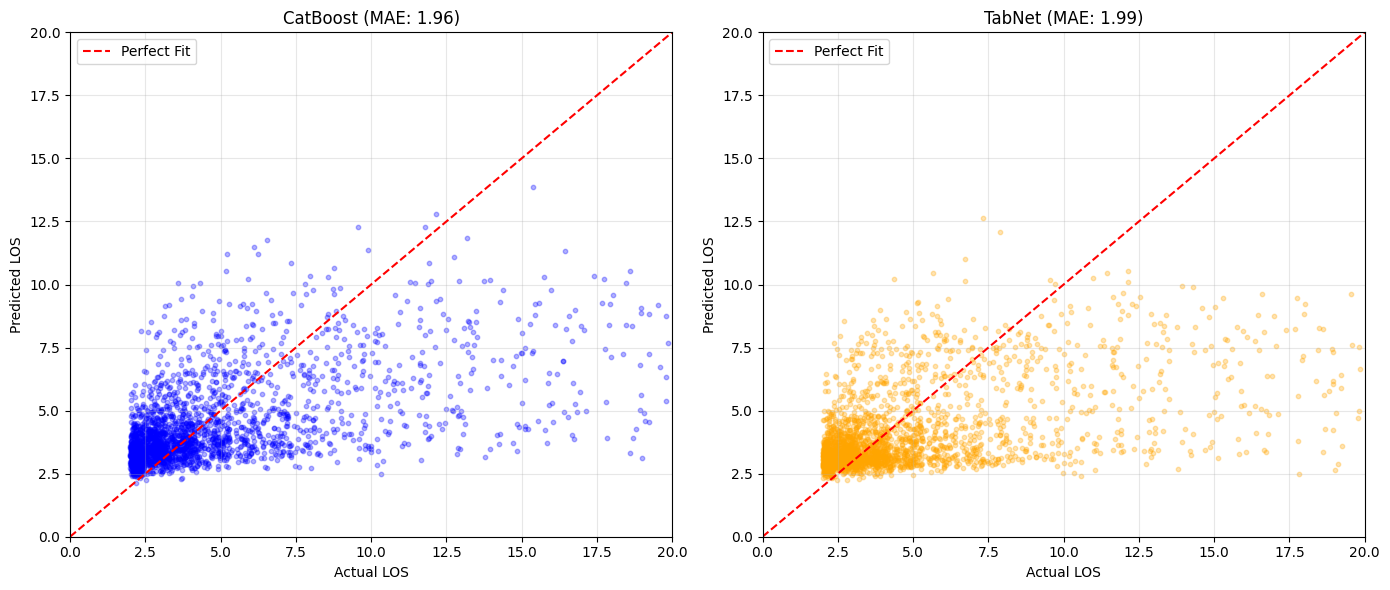

In [ ]:
print("\n--- [Final Step] 최종 결과 비교 ---")
print(f"CatBoost MAE: {mae_cat:.4f}")
print(f"TabNet   MAE: {mae_tab:.4f}")

# 시각화 (Actual vs Predicted Scatter Plot)
plt.figure(figsize=(14, 6))

# CatBoost Plot
plt.subplot(1, 2, 1)
plt.scatter(np.expm1(y_test), np.expm1(pred_cat), alpha=0.3, s=10, color='blue')
plt.plot([0, 20], [0, 20], 'r--', label='Perfect Fit')
plt.title(f'CatBoost (MAE: {mae_cat:.2f})')
plt.xlabel('Actual LOS')
plt.ylabel('Predicted LOS')
plt.xlim(0, 20); plt.ylim(0, 20)
plt.legend()
plt.grid(True, alpha=0.3)

# TabNet Plot
plt.subplot(1, 2, 2)
plt.scatter(np.expm1(y_test_np), np.expm1(pred_tab), alpha=0.3, s=10, color='orange')
plt.plot([0, 20], [0, 20], 'r--', label='Perfect Fit')
plt.title(f'TabNet (MAE: {mae_tab:.2f})')
plt.xlabel('Actual LOS')
plt.ylabel('Predicted LOS')
plt.xlim(0, 20); plt.ylim(0, 20)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- [TabNet K-Fold Cross Validation] ---")

from sklearn.model_selection import KFold

# 5-Fold 설정
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

tab_cv_scores = []

# 범주형 변수 정보 (Embedding용) - 전체 데이터 기준 고정
cat_idxs = [i for i, f in enumerate(X_processed.columns) if f in cat_cols]
cat_dims = [len(X_processed[col].unique()) for col in cat_cols]

print(f"TabNet {n_folds}-Fold 검증 시작 (시간이 걸릴 수 있습니다)...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_processed, y)):
    print(f"\n[Fold {fold+1}/{n_folds}]")

    # 1. 데이터 분할
    # (X_processed는 Label Encoding만 된 상태)
    X_train_k = X_processed.iloc[train_idx].copy()
    X_val_k = X_processed.iloc[val_idx].copy()
    y_train_k = y.iloc[train_idx].values.reshape(-1, 1)
    y_val_k = y.iloc[val_idx].values.reshape(-1, 1)

    # 2. 스케일링 (수치형 변수만) - [중요] Loop 안에서 수행!
    scaler = StandardScaler()
    X_train_k[num_cols] = scaler.fit_transform(X_train_k[num_cols])
    X_val_k[num_cols] = scaler.transform(X_val_k[num_cols])

    # 3. Numpy 변환
    X_train_k = X_train_k.values
    X_val_k = X_val_k.values

    # 4. 모델 초기화 (Best Params 사용)
    # (study_tab이 없다면 기본 파라미터나 임의의 값 사용)
    best_params = study_tab.best_params if 'study_tab' in locals() else {}

    # best_params에 cat_idxs 등이 없으므로 추가
    model_params = best_params.copy()
    model_params['cat_idxs'] = cat_idxs
    model_params['cat_dims'] = cat_dims
    model_params['cat_emb_dim'] = 1
    model_params['optimizer_params'] = dict(lr=0.02)
    model_params['verbose'] = 0
    model_params['seed'] = 42

    tab_model = TabNetRegressor(**model_params)

    # 5. 학습
    tab_model.fit(
        X_train_k, y_train_k,
        eval_set=[(X_val_k, y_val_k)],
        eval_metric=['mae'],
        patience=10,
        max_epochs=50, # K-Fold는 오래 걸리므로 Epoch 조절 (실전엔 100 추천)
        batch_size=1024,
        virtual_batch_size=128
    )

    # 6. 예측 및 평가
    preds = tab_model.predict(X_val_k)
    mae = mean_absolute_error(np.expm1(y_val_k), np.expm1(preds))
    tab_cv_scores.append(mae)

    print(f"  >> Fold {fold+1} MAE: {mae:.4f}")

# 최종 결과
print("\n==========================================")
print(f"TabNet {n_folds}-Fold 평균 MAE: {np.mean(tab_cv_scores):.4f} ± {np.std(tab_cv_scores):.4f}")
print("==========================================")


--- [TabNet K-Fold Cross Validation] ---
TabNet 5-Fold 검증 시작 (시간이 걸릴 수 있습니다)...

[Fold 1/5]
Stop training because you reached max_epochs = 50 with best_epoch = 44 and best_val_0_mae = 0.31046


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  >> Fold 1 MAE: 2.0050

[Fold 2/5]

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_0_mae = 0.31902


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  >> Fold 2 MAE: 2.0273

[Fold 3/5]

Early stopping occurred at epoch 48 with best_epoch = 38 and best_val_0_mae = 0.30627


...

  >> Fold 3 MAE: 1.9618

[Fold 4/5]
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_val_0_mae = 0.31665


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  >> Fold 4 MAE: 2.0770

[Fold 5/5]

Early stopping occurred at epoch 23 with best_epoch = 13 and best_val_0_mae = 0.32593


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


  >> Fold 5 MAE: 2.1100

TabNet 5-Fold 평균 MAE: 2.0362 ± 0.0523



--- [Step 7] SHAP Analysis (XAI) ---


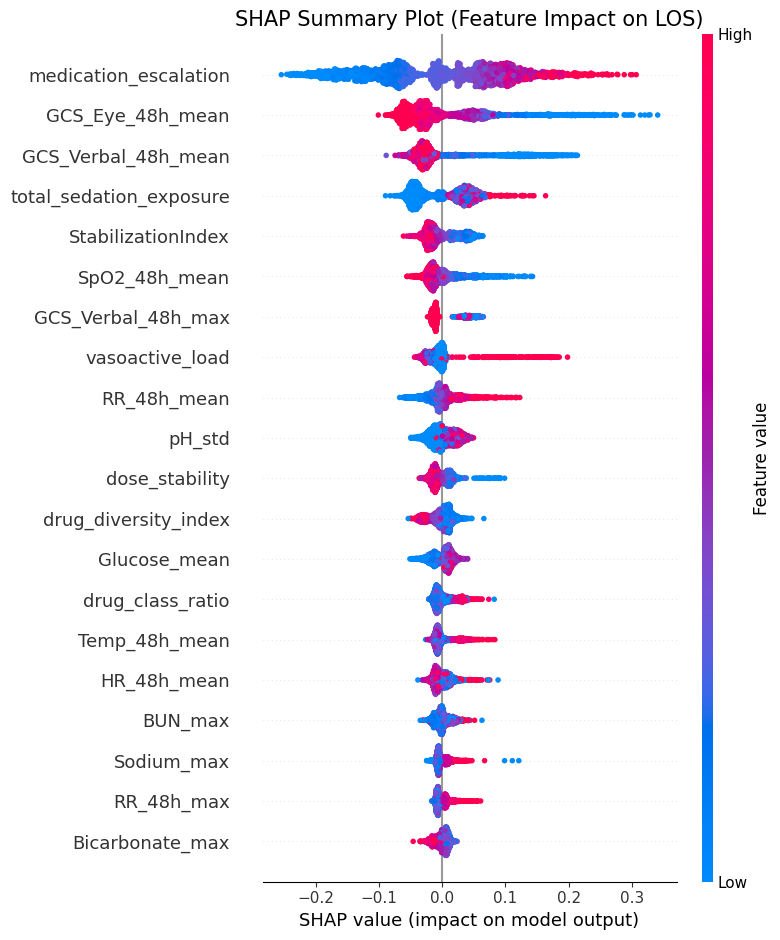

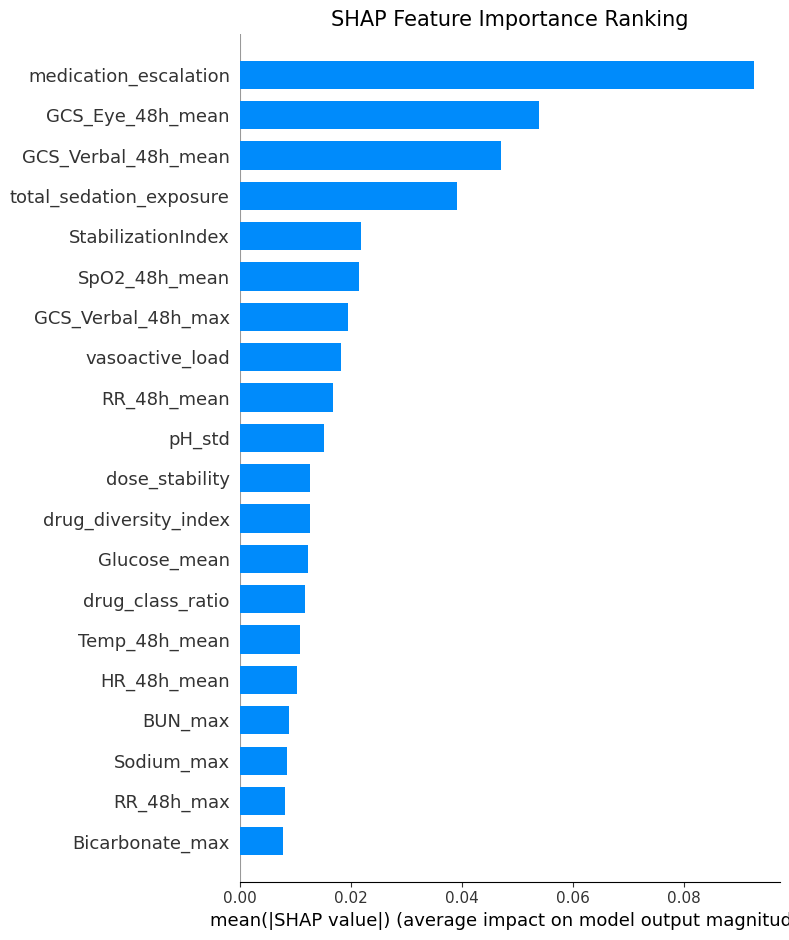


[개별 환자 분석 예시 (첫 번째 Test 환자)]


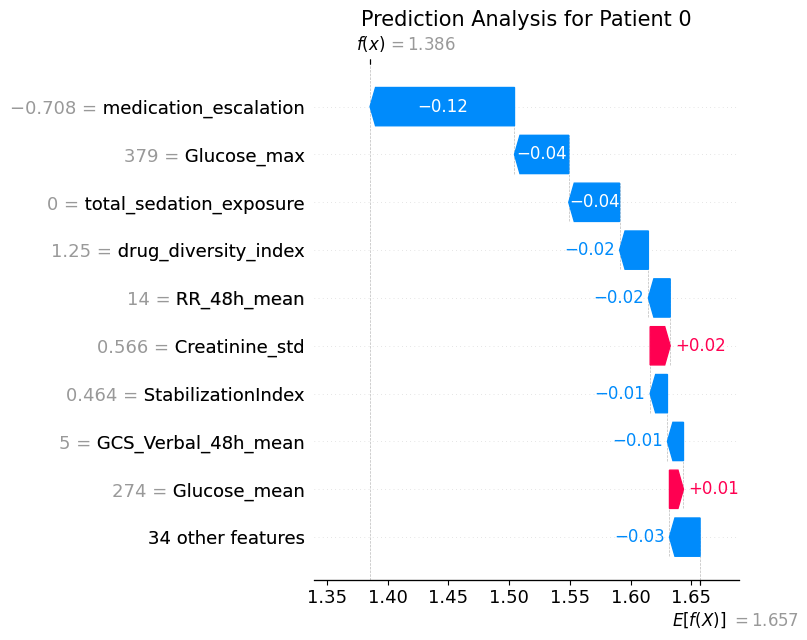

In [ ]:
print("\n--- [Step 7] SHAP Analysis (XAI) ---")

# 1. SHAP Explainer 생성
explainer = shap.TreeExplainer(best_cat)

# 2. SHAP 값 계산 (데이터가 너무 많으면 일부만 사용)
# (전체 데이터를 쓰려면 X_test 그대로 사용)
shap_values = explainer.shap_values(X_test)

# 3. Summary Plot (전체적인 영향력)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (Feature Impact on LOS)", fontsize=15)
plt.tight_layout()
plt.show()

# 4. Bar Plot (중요도 순위)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance Ranking", fontsize=15)
plt.tight_layout()
plt.show()

# 5. 개별 환자 분석 (Waterfall Plot)
print("\n[개별 환자 분석 예시 (첫 번째 Test 환자)]")

# Explainer의 expected_value(기준값) 추출 (리스트일 경우 처리)
base_value = explainer.expected_value
if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
    base_value = base_value[0]

# Explanation 객체 생성
explanation = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=X_test,
    feature_names=X_test.columns
)

plt.figure(figsize=(10, 6))
# 첫 번째 환자([0])에 대한 Waterfall Plot
shap.plots.waterfall(explanation[0], show=False)
plt.title(f"Prediction Analysis for Patient 0", fontsize=15)
plt.tight_layout()
plt.show()

오차 분석 (Error Analysis)


--- [Step 8] Error Analysis & Segmented Evaluation ---

[구간별 성능 상세 리포트]
▶ 2~3 days
  Count       : 913
  True Mean   : 2.428
  Pred Mean   : 3.598
  MAE         : 1.175
  RMSE        : 1.420

▶ 3~4 days
  Count       : 510
  True Mean   : 3.459
  Pred Mean   : 4.047
  MAE         : 0.857
  RMSE        : 1.342

▶ 4~5 days
  Count       : 279
  True Mean   : 4.474
  Pred Mean   : 4.507
  MAE         : 1.122
  RMSE        : 1.492

▶ 5~7 days
  Count       : 299
  True Mean   : 5.854
  Pred Mean   : 5.034
  MAE         : 1.764
  RMSE        : 2.052

▶ 7+ days
  Count       : 459
  True Mean   : 11.389
  Pred Mean   : 6.153
  MAE         : 5.376
  RMSE        : 6.475



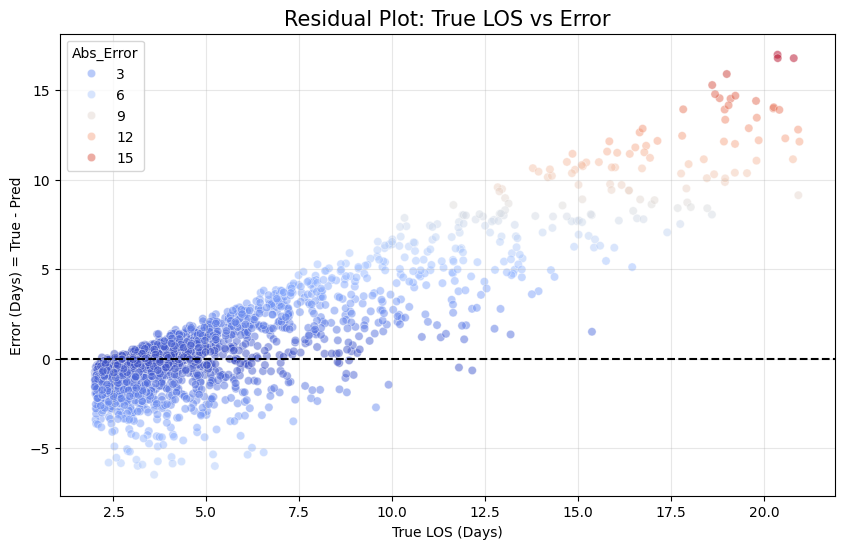

In [ ]:
print("\n--- [Step 8] Error Analysis & Segmented Evaluation ---")

# 1. 예측값 및 오차 계산 (CatBoost 기준)
# (이미 pred_cat이 계산되어 있지만, 확실히 하기 위해 다시 예측)
pred_log = best_cat.predict(test_pool)
pred_days = np.expm1(pred_log)
true_days = np.expm1(y_test)

# 오차 데이터프레임 생성
error_df = pd.DataFrame({
    'True_LOS': true_days,
    'Pred_LOS': pred_days,
    'Error': true_days - pred_days,
    'Abs_Error': np.abs(true_days - pred_days)
})

# 2. 구간별 성능 평가 함수 (조장님 스타일)
def print_bin_stats(df, label):
    if len(df) == 0: return

    t_mean = df['True_LOS'].mean()
    p_mean = df['Pred_LOS'].mean()
    mae = mean_absolute_error(df['True_LOS'], df['Pred_LOS'])
    rmse = np.sqrt(mean_squared_error(df['True_LOS'], df['Pred_LOS']))

    print(f"▶ {label}")
    print(f"  Count       : {len(df)}")
    print(f"  True Mean   : {t_mean:.3f}")
    print(f"  Pred Mean   : {p_mean:.3f}")
    print(f"  MAE         : {mae:.3f}")
    print(f"  RMSE        : {rmse:.3f}")
    print("") # 줄바꿈

# 구간 설정 (0~2, 2~3, 3~4, 4~5, 5~7, 7+)
# (조장님 기준에 0~2일 구간도 추가하는 것이 좋습니다)
bins = [0, 2, 3, 4, 5, 7, 100]
labels = ['0~2 days', '2~3 days', '3~4 days', '4~5 days', '5~7 days', '7+ days']

error_df['Bin'] = pd.cut(error_df['True_LOS'], bins=bins, labels=labels, right=False)

print("\n[구간별 성능 상세 리포트]")
for label in labels:
    subset = error_df[error_df['Bin'] == label]
    print_bin_stats(subset, label)

# 3. Residual Plot (잔차도)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='True_LOS', y='Error', data=error_df, alpha=0.5, hue='Abs_Error', palette='coolwarm')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Plot: True LOS vs Error", fontsize=15)
plt.xlabel("True LOS (Days)")
plt.ylabel("Error (Days) = True - Pred")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

print("\n--- [추가] RMSE 성능 평가 ---")

# 1. CatBoost RMSE 계산
rmse_cat = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_cat)))
print(f"CatBoost RMSE: {rmse_cat:.4f}")

# 2. TabNet RMSE 계산
rmse_tab = np.sqrt(mean_squared_error(np.expm1(y_test_np), np.expm1(pred_tab)))
print(f"TabNet   RMSE: {rmse_tab:.4f}")

# (참고) 일반적으로 RMSE는 MAE보다 항상 큽니다.
# RMSE가 MAE보다 훨씬 크다면, 모델이 가끔씩 아주 크게 틀리는 경우(이상치)가 많다는 뜻입니다.


--- [추가] RMSE 성능 평가 ---
CatBoost RMSE: 3.1161
TabNet   RMSE: 3.2737
